In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load California Housing Dataset

data = fetch_california_housing(as_frame=True)

df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Separate Features and Target

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [4]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [5]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [6]:
# Create Models

linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train Models

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [8]:
# Predictions

linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

# Evaluation Function

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return [name, round(rmse, 3), round(r2, 3)]

results = [
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Ridge Regression", y_test, ridge_pred),
    evaluate_model("Decision Tree", y_test, tree_pred)
]

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])

results_df

,Model,RMSE,R2 Score
0,Linear Regression,0.746,0.576
1,Ridge Regression,0.746,0.576
2,Decision Tree,0.724,0.600


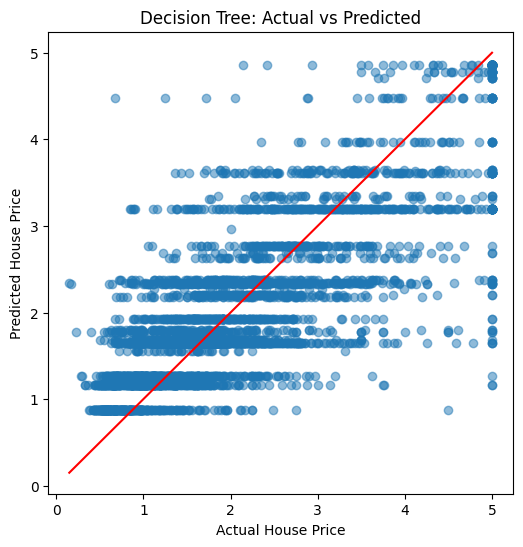

In [9]:
# Actual vs Predicted Graph (Best Model)

best_pred = tree_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, best_pred, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()